Puedes pedir versiones impresas y ebook de *Think Python 3e* en
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) y
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');
download('https://github.com/ramalho/jupyturtle/releases/download/2024-03/jupyturtle.py');

import thinkpython

Downloaded thinkpython.py
Downloaded diagram.py
Downloaded jupyturtle.py


# Clases y Objetos

Hasta este punto hemos definido clases y creado objetos que representan la hora del día y el día del año.
Y hemos definido métodos que crean, modifican y realizan cálculos con estos objetos.

En este capítulo continuaremos nuestro recorrido por la programación orientada a objetos (OOP) definiendo clases que representan objetos geométricos, incluidos puntos, líneas, rectángulos y círculos.
Escribiremos métodos que crean y modifican estos objetos, y usaremos el module `jupyturtle` para dibujarlos.

Usaré estas clases para demostrar temas de OOP, incluida la identidad y equivalencia de objetos, las copias superficiales y profundas, y el polimorfismo.

## Crear un Point

En gráficos por computadora, una ubicación en la pantalla a menudo se representa usando un par de coordenadas en un plano `x`-`y`.
Por convención, el punto `(0, 0)` suele representar la esquina superior izquierda de la pantalla, y `(x, y)` representa el punto que está `x` unidades a la derecha e `y` unidades hacia abajo desde el origen.
Comparado con el sistema de coordenadas cartesianas que quizá hayas visto en una clase de matemáticas, el eje `y` está al revés.

Hay varias formas en que podríamos representar un punto en Python:

-   Podemos almacenar las coordenadas por separado en dos variables, `x` e `y`.

-   Podemos almacenar las coordenadas como elementos en una lista o tupla.

-   Podemos crear un nuevo tipo para representar puntos como objetos.

En programación orientada a objetos, lo más idiomático sería crear un nuevo tipo.
Para hacerlo, empezaremos con una definición de clase para `Point`.

In [2]:
class Point:
    """Represents a point in 2-D space."""

    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __str__(self):
        return f'Point({self.x}, {self.y})'

El método `__init__` toma las coordenadas como parámetros y las asigna a los atributos `x` e `y`.
El método `__str__` devuelve una representación en string del `Point`.

Ahora podemos instanciar y mostrar un objeto `Point` así.

In [3]:
start = Point(0, 0)
print(start)

Point(0, 0)


El siguiente diagrama muestra el estado del nuevo objeto.

In [4]:
from diagram import make_frame, make_binding

d1 = vars(start)
frame = make_frame(d1, name='Point', dy=-0.25, offsetx=0.18)
binding = make_binding('start', frame)

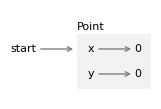

In [5]:
from diagram import diagram, adjust

width, height, x, y = [1.41, 0.89, 0.26, 0.5]
ax = diagram(width, height)
bbox = binding.draw(ax, x, y)
#adjust(x, y, bbox)

Como de costumbre, un tipo definido por el programador se representa con una caja con el nombre del tipo fuera y los atributos dentro.

En general, los tipos definidos por el programador son mutables, así que podemos escribir un método como `translate` que tome dos números, `dx` y `dy`, y los sume a los atributos `x` e `y`.

In [6]:
%%add_method_to Point

    def translate(self, dx, dy):
        self.x += dx
        self.y += dy

Esta función traslada el `Point` de una ubicación del plano a otra.
Si no queremos modificar un `Point` existente, podemos usar `copy` para copiar el objeto original y luego modificar la copia.

In [7]:
from copy import copy

end1 = copy(start)
end1.translate(300, 0)
print(end1)

Point(300, 0)


Podemos encapsular esos pasos en otro método llamado `translated`.

In [8]:
%%add_method_to Point

    def translated(self, dx=0, dy=0):
        point = copy(self)
        point.translate(dx, dy)
        return point

De la misma manera que el método `sort` modifica una lista y la función `sorted` crea una lista nueva, ahora tenemos un método `translate` que modifica un `Point` y un método `translated` que crea uno nuevo.

Aquí hay un ejemplo:

In [9]:
end2 = start.translated(0, 150)
print(end2)

Point(0, 150)


En la siguiente sección, usaremos estos puntos para definir y dibujar una línea.

## Crear una Line

Ahora definamos una clase que representa el segmento de línea entre dos puntos.
Como de costumbre, empezaremos con un método `__init__` y un método `__str__`.

In [10]:
class Line:
    def __init__(self, p1, p2):
        self.p1 = p1
        self.p2 = p2

    def __str__(self):
        return f'Line({self.p1}, {self.p2})'

Con esos dos métodos, podemos instanciar y mostrar un objeto `Line` que usaremos para representar el eje `x`.

In [11]:
line1 = Line(start, end1)
print(line1)

Line(Point(0, 0), Point(300, 0))


Cuando llamamos a `print` y pasamos `line` como parámetro, `print` invoca `__str__` sobre `line`.
El método `__str__` usa un f-string para crear una representación en string de la `line`.

El f-string contiene dos expresiones entre llaves, `self.p1` y `self.p2`.
Cuando se evalúan esas expresiones, los resultados son objetos `Point`.
Luego, cuando se convierten a strings, se invoca el método `__str__` de la clase `Point`.

Por eso, cuando mostramos una `Line`, el resultado contiene las representaciones en string de los objetos `Point`.

El siguiente diagrama de objeto muestra el estado de este objeto `Line`.

In [12]:
from diagram import Binding, Value, Frame

d1 = vars(line1.p1)
frame1 = make_frame(d1, name='Point', dy=-0.25, offsetx=0.17)

d2 = vars(line1.p2)
frame2 = make_frame(d2, name='Point', dy=-0.25, offsetx=0.17)

binding1 = Binding(Value('start'), frame1, dx=0.4)
binding2 = Binding(Value('end'), frame2, dx=0.4)
frame3 = Frame([binding1, binding2], name='Line', dy=-0.9, offsetx=0.4, offsety=-0.25)

binding = make_binding('line1', frame3)

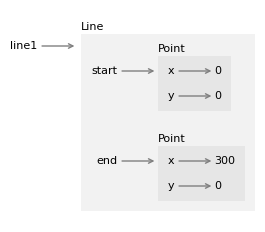

In [13]:
width, height, x, y = [2.45, 2.12, 0.27, 1.76]
ax = diagram(width, height)
bbox = binding.draw(ax, x, y)
#adjust(x, y, bbox)

Las representaciones en string y los diagramas de objeto son útiles para depurar, ¡pero el objetivo de este ejemplo es generar gráficos, no texto!
Así que usaremos el module `jupyturtle` para dibujar líneas en la pantalla.

Como hicimos en el [Capítulo 4](section_turtle_module), usaremos `make_turtle` para crear un objeto `Turtle` y un canvas pequeño donde pueda dibujar.
Para dibujar líneas, usaremos dos funciones nuevas del module `jupyturtle`:

* `jumpto`, que toma dos coordenadas y mueve la `Turtle` a la ubicación dada sin dibujar una línea, y

* `moveto`, que mueve la `Turtle` desde su ubicación actual a la ubicación dada, y dibuja un segmento de línea entre ellas.

Así es como las importamos.

In [14]:
from jupyturtle import make_turtle, jumpto, moveto

Y aquí hay un método que dibuja una `Line`.

In [15]:
%%add_method_to Line

    def draw(self):
        jumpto(self.p1.x, self.p1.y)
        moveto(self.p2.x, self.p2.y)

Para mostrar cómo se usa, crearé una segunda línea que representa el eje `y`.

In [16]:
line2 = Line(start, end2)
print(line2)

Line(Point(0, 0), Point(0, 150))


Y luego dibujamos los ejes.

In [18]:
make_turtle()
line1.draw()
line2.draw()

A medida que definamos y dibujemos más objetos, usaremos estas líneas otra vez.
Pero primero hablemos de equivalencia e identidad de objetos.

## Equivalencia e identidad

Supongamos que creamos dos puntos con las mismas coordenadas.

In [19]:
p1 = Point(200, 100)
p2 = Point(200, 100)

Si usamos el operador `==` para compararlos, obtenemos el comportamiento por defecto para tipos definidos por el programador -- el resultado es `True` solo si son el mismo objeto, y no lo son.

In [20]:
p1 == p2

False

Si queremos cambiar ese comportamiento, podemos proporcionar un método especial llamado `__eq__` que define qué significa que dos objetos `Point` sean iguales.

In [21]:
%%add_method_to Point

def __eq__(self, other):
    return (self.x == other.x) and (self.y == other.y)

Esta definición considera que dos `Points` son iguales si sus atributos son iguales.
Ahora, cuando usamos el operador `==`, invoca el método `__eq__`, que indica que `p1` y `p2` se consideran iguales.

In [22]:
p1 == p2

True

Pero el operador `is` todavía indica que son objetos diferentes.

In [23]:
p1 is p2

False

No es posible sobrescribir el operador `is` -- siempre comprueba si los objetos son idénticos.
Pero para tipos definidos por el programador, puedes sobrescribir el operador `==` para que compruebe si los objetos son equivalentes.
Y puedes definir qué significa equivalente.

## Crear un Rectangle

Ahora definamos una clase que representa y dibuja rectángulos.
Para simplificar las cosas, asumiremos que los rectángulos son verticales u horizontales, no inclinados.
¿Qué atributos crees que deberíamos usar para especificar la ubicación y el tamaño de un rectángulo?

Hay al menos dos posibilidades:

-   Podrías especificar el ancho y alto del rectángulo y la ubicación de una esquina.

-   Podrías especificar dos esquinas opuestas.

En este punto es difícil decir si una es mejor que la otra, así que implementemos la primera.
Aquí está la definición de la clase.

In [24]:
class Rectangle:
    """Represents a rectangle.

    attributes: width, height, corner.
    """
    def __init__(self, width, height, corner):
        self.width = width
        self.height = height
        self.corner = corner

    def __str__(self):
        return f'Rectangle({self.width}, {self.height}, {self.corner})'

Como de costumbre, el método `__init__` asigna los parámetros a atributos y `__str__` devuelve una representación en string del objeto.
Ahora podemos instanciar un objeto `Rectangle`, usando un `Point` como ubicación de la esquina superior izquierda.

In [25]:
corner = Point(30, 20)
box1 = Rectangle(100, 50, corner)
print(box1)

Rectangle(100, 50, Point(30, 20))


El siguiente diagrama muestra el estado de este objeto.

In [26]:
from diagram import Binding, Value

def make_rectangle_binding(name, box, **options):
    d1 = vars(box.corner)
    frame_corner = make_frame(d1, name='Point', dy=-0.25, offsetx=0.07)

    d2 = dict(width=box.width, height=box.height)
    frame = make_frame(d2, name='Rectangle', dy=-0.25, offsetx=0.45)
    binding = Binding(Value('corner'), frame1, dx=0.92, draw_value=False, **options)
    frame.bindings.append(binding)

    binding = Binding(Value(name), frame)
    return binding, frame_corner

binding_box1, frame_corner1 = make_rectangle_binding('box1', box1)

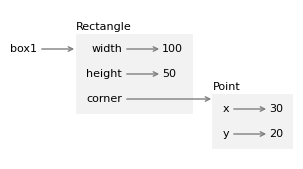

In [27]:
from diagram import Bbox

width, height, x, y = [2.83, 1.49, 0.27, 1.1]
ax = diagram(width, height)
bbox1 = binding_box1.draw(ax, x, y)
bbox2 = frame_corner1.draw(ax, x+1.85, y-0.6)
bbox = Bbox.union([bbox1, bbox2])
#adjust(x, y, bbox)

Para dibujar un rectángulo, usaremos el siguiente método para crear cuatro objetos `Point` que representen las esquinas.

In [28]:
%%add_method_to Rectangle

    def make_points(self):
        p1 = self.corner
        p2 = p1.translated(self.width, 0)
        p3 = p2.translated(0, self.height)
        p4 = p3.translated(-self.width, 0)
        return p1, p2, p3, p4

Luego crearemos cuatro objetos `Line` para representar los lados.

In [29]:
%%add_method_to Rectangle

    def make_lines(self):
        p1, p2, p3, p4 = self.make_points()
        return Line(p1, p2), Line(p2, p3), Line(p3, p4), Line(p4, p1)

Luego dibujaremos los lados.

In [30]:
%%add_method_to Rectangle

    def draw(self):
        lines = self.make_lines()
        for line in lines:
            line.draw()

Aquí hay un ejemplo.

In [31]:
make_turtle()
line1.draw()
line2.draw()
box1.draw()

La figura incluye dos líneas para representar los ejes.

## Cambiar rectángulos

Ahora consideremos dos métodos que modifican rectángulos, `grow` y `translate`.
Veremos que `grow` funciona como se esperaba, pero `translate` tiene un error sutil.
A ver si puedes descubrirlo antes de que lo explique.

`grow` toma dos números, `dwidth` y `dheight`, y los suma a los atributos `width` y `height` del rectángulo.

In [32]:
%%add_method_to Rectangle

    def grow(self, dwidth, dheight):
        self.width += dwidth
        self.height += dheight

Aquí hay un ejemplo que demuestra el efecto creando una copia de `box1` e invocando `grow` sobre la copia.

In [33]:
box2 = copy(box1)
box2.grow(60, 40)
print(box2)

Rectangle(160, 90, Point(30, 20))


Si dibujamos `box1` y `box2`, podemos confirmar que `grow` funciona como se esperaba.

In [34]:
make_turtle()
line1.draw()
line2.draw()
box1.draw()
box2.draw()

Ahora veamos qué pasa con `translate`.
Toma dos números, `dx` y `dy`, y mueve el rectángulo las distancias dadas en las direcciones `x` e `y`.

In [35]:
%%add_method_to Rectangle

    def translate(self, dx, dy):
        self.corner.translate(dx, dy)

Para demostrar el efecto, trasladaremos `box2` a la derecha y hacia abajo.

In [36]:
box2.translate(30, 20)
print(box2)

Rectangle(160, 90, Point(60, 40))


Ahora veamos qué pasa si dibujamos `box1` y `box2` otra vez.

In [37]:
make_turtle()
line1.draw()
line2.draw()
box1.draw()
box2.draw()

Parece que ambos rectángulos se movieron, ¡que no era lo que pretendíamos!
La siguiente sección explica qué salió mal.

## Copia profunda

Cuando usamos `copy` para duplicar `box1`, copia el objeto `Rectangle` pero no el objeto `Point` que contiene.
Así que `box1` y `box2` son objetos diferentes, como pretendíamos.

In [38]:
box1 is box2

False

Pero sus atributos `corner` se refieren al mismo objeto.

In [39]:
box1.corner is box2.corner

True

El siguiente diagrama muestra el estado de estos objetos.

In [40]:
from diagram import Stack
from copy import deepcopy

binding_box1, frame_corner1 = make_rectangle_binding('box1', box1)
binding_box2, frame_corner2 = make_rectangle_binding('box2', box2, dy=0.4)
binding_box2.value.bindings.reverse()

stack = Stack([binding_box1, binding_box2], dy=-1.3)

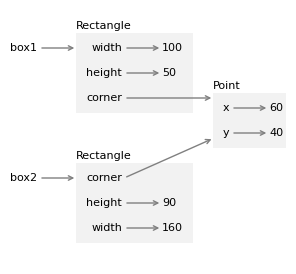

In [41]:
from diagram import Bbox

width, height, x, y = [2.76, 2.54, 0.27, 2.16]
ax = diagram(width, height)
bbox1 = stack.draw(ax, x, y)
bbox2 = frame_corner1.draw(ax, x+1.85, y-0.6)
bbox = Bbox.union([bbox1, bbox2])
# adjust(x, y, bbox)

Lo que hace `copy` se llama **copia superficial** porque copia el objeto pero no los objetos que contiene.
Como resultado, cambiar el `width` o `height` de un `Rectangle` no afecta al otro, ¡pero cambiar los atributos del `Point` compartido afecta a ambos!
Este comportamiento es confuso y propenso a errores.

Afortunadamente, el module `copy` proporciona otra función, llamada `deepcopy`, que copia no solo el objeto sino también los objetos a los que se refiere, y los objetos a los que *ellos* se refieren, y así sucesivamente.
Esta operación se llama **copia profunda**.

Para demostrarlo, empecemos con un nuevo `Rectangle` que contiene un nuevo `Point`.

In [42]:
corner = Point(20, 20)
box3 = Rectangle(100, 50, corner)
print(box3)

Rectangle(100, 50, Point(20, 20))


Y haremos una copia profunda.

In [43]:
from copy import deepcopy

box4 = deepcopy(box3)

Podemos confirmar que los dos objetos `Rectangle` se refieren a objetos `Point` diferentes.

In [44]:
box3.corner is box4.corner

False

Como `box3` y `box4` son objetos completamente separados, podemos modificar uno sin afectar al otro.
Para demostrarlo, moveremos `box3` y haremos crecer `box4`.

In [45]:
box3.translate(50, 30)
box4.grow(100, 60)

Y podemos confirmar que el efecto es el esperado.

In [46]:
make_turtle()
line1.draw()
line2.draw()
box3.draw()
box4.draw()

## Polimorfismo

En el ejemplo anterior, invocamos el método `draw` sobre dos objetos `Line` y dos objetos `Rectangle`.
Podemos hacer lo mismo de forma más concisa creando una lista de objetos.

In [47]:
shapes = [line1, line2, box3, box4]

Los elementos de esta lista son de tipos diferentes, pero todos proporcionan un método `draw`, así que podemos recorrer la lista e invocar `draw` sobre cada uno.

In [48]:
make_turtle()

for shape in shapes:
    shape.draw()

La primera y segunda vez a través del bucle, `shape` se refiere a un objeto `Line`, así que cuando se invoca `draw`, el método que se ejecuta es el definido en la clase `Line`.

La tercera y cuarta vez a través del bucle, `shape` se refiere a un objeto `Rectangle`, así que cuando se invoca `draw`, el método que se ejecuta es el definido en la clase `Rectangle`.

En cierto sentido, cada objeto sabe cómo dibujarse a sí mismo.
Esta característica se llama **polimorfismo**.
La palabra viene de raíces griegas que significan "muchas formas".
En programación orientada a objetos, el polimorfismo es la capacidad de diferentes tipos para proporcionar los mismos métodos, lo que hace posible realizar muchos cálculos -- como dibujar formas -- invocando el mismo método sobre objetos de tipos diferentes.

Como ejercicio al final de este capítulo, definirás una nueva clase que representa un círculo y proporciona un método `draw`.
Luego puedes usar polimorfismo para dibujar líneas, rectángulos y círculos.

## Depuración

En este capítulo, nos encontramos con un error sutil que ocurrió porque creamos un `Point` que era compartido por dos objetos `Rectangle`, y luego modificamos el `Point`.
En general, hay dos formas de evitar problemas como este: puedes evitar compartir objetos o puedes evitar modificarlos.

Para evitar compartir objetos, puedes usar copia profunda, como hicimos en este capítulo.

Para evitar modificar objetos, considera reemplazar funciones impuras como `translate` por funciones puras como `translated`.
Por ejemplo, aquí hay una versión de `translated` que crea un nuevo `Point` y nunca modifica sus atributos.

In [49]:
    def translated(self, dx=0, dy=0):
        x = self.x + dx
        y = self.y + dy
        return Point(x, y)

Python proporciona funcionalidades que hacen más fácil evitar modificar objetos.
Están fuera del alcance de este libro, pero si tienes curiosidad, pregunta a un asistente virtual: "¿Cómo hago que un objeto de Python sea inmutable?"

Crear un objeto nuevo toma más tiempo que modificar uno existente, pero la diferencia rara vez importa en la práctica.
Los programas que evitan objetos compartidos y funciones impuras suelen ser más fáciles de desarrollar, probar y depurar -- y la mejor depuración es el que no tienes que hacer.

## Glosario

**copia superficial:**
Una operación de copia que no copia objetos anidados.

**copia profunda:**
Una operación de copia que también copia objetos anidados.

**polimorfismo:**
La capacidad de un método u operador para funcionar con múltiples tipos de objetos.

## Ejercicios

In [50]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### Pregunta a un asistente virtual

Para todos los ejercicios siguientes, considera pedir ayuda a un asistente virtual.
Si lo haces, querrás incluir como parte del prompt las definiciones de clase para `Point`, `Line` y `Rectangle` -- de lo contrario el AV hará una suposición sobre sus atributos y funciones, y el código que genere no funcionará.

### Ejercicio

Escribe un método `__eq__` para la clase `Line` que devuelva `True` si los objetos `Line` se refieren a objetos `Point` que son equivalentes, en cualquier orden.

Puedes usar el siguiente esquema para empezar.

In [51]:
%%add_method_to Line

def __eq__(self, other):
    return ((self.p1 == other.p1 and self.p2 == other.p2) or
            (self.p1 == other.p2 and self.p2 == other.p1))

In [ ]:
# Solution goes here

Puedes usar estos ejemplos para probar tu código.

In [52]:
start1 = Point(0, 0)
start2 = Point(0, 0)
end = Point(200, 100)

Este ejemplo debería ser `True` porque los objetos `Line` se refieren a objetos `Point` que son equivalentes, en el mismo orden.

In [53]:
line_a = Line(start1, end)
line_b = Line(start2, end)
line_a == line_b    # should be True

True

Este ejemplo debería ser `True` porque los objetos `Line` se refieren a objetos `Point` que son equivalentes, en orden inverso.

In [54]:
line_c = Line(end, start1)
line_a == line_c     # should be True

True

La equivalencia siempre debería ser transitiva -- es decir, si `line_a` y `line_b` son equivalentes, y `line_a` y `line_c` son equivalentes, entonces `line_b` y `line_c` también deberían ser equivalentes.

In [55]:
line_b == line_c     # should be True

True

Este ejemplo debería ser `False` porque los objetos `Line` se refieren a objetos `Point` que no son equivalentes.

In [56]:
line_d = Line(start1, start2)
line_a == line_d    # should be False

False

### Ejercicio

Escribe un método de `Line` llamado `midpoint` que calcule el punto medio de un segmento de línea y devuelva el resultado como un objeto `Point`.

Puedes usar el siguiente esquema para empezar.

In [58]:
%%add_method_to Line

    def midpoint(self):
        x = (self.p1.x + self.p2.x)/2
        y = (self.p1.y + self.p2.y) / 2
        return Point(x, y)

In [ ]:
# Solution goes here

Puedes usar los siguientes ejemplos para probar tu código y dibujar el resultado.

In [59]:
start = Point(0, 0)
end1 = Point(300, 0)
end2 = Point(0, 150)
line1 = Line(start, end1)
line2 = Line(start, end2)

In [60]:
mid1 = line1.midpoint()
print(mid1)

Point(150.0, 0.0)


In [61]:
mid2 = line2.midpoint()
print(mid2)

Point(0.0, 75.0)


In [62]:
line3 = Line(mid1, mid2)

In [63]:
make_turtle()

for shape in [line1, line2, line3]:
    shape.draw()

### Ejercicio

Escribe un método de `Rectangle` llamado `midpoint` que encuentre el punto en el centro de un rectángulo y devuelva el resultado como un objeto `Point`.

Puedes usar el siguiente esquema para empezar.

In [65]:
%%add_method_to Rectangle

    def midpoint(self):
        x = self.corner.x + (self.width / 2)
        y = self.corner.y + (self.height / 2)

        return Point(x, y)

In [ ]:
# Solution goes here

Puedes usar el siguiente ejemplo para probar tu código.

In [70]:
corner = Point(30, 20)
rectangle = Rectangle(100, 80, corner)

In [71]:
mid = rectangle.midpoint()
print(mid)

Point(80.0, 60.0)


In [72]:
diagonal = Line(corner, mid)

In [69]:
make_turtle()

for shape in [line1, line2, rectangle, diagonal]:
    shape.draw()

### Ejercicio

Escribe un método de `Rectangle` llamado `make_cross` que:

1. Use `make_lines` para obtener una lista de objetos `Line` que representan los cuatro lados del rectángulo.

2. Calcule los puntos medios de las cuatro líneas.

3. Cree y devuelva una lista de dos objetos `Line` que representan líneas que conectan puntos medios opuestos, formando una cruz por el centro del rectángulo.

Puedes usar este esquema para empezar.

In [76]:
%%add_method_to Rectangle

    def make_cross(self):
        lines = self.make_lines()

        mid1 = lines[0].midpoint()   # lado superior
        mid2 = lines[1].midpoint()   # lado derecho
        mid3 = lines[2].midpoint()   # lado inferior
        mid4 = lines[3].midpoint()   # lado izquierdo

        vertical = Line(mid1, mid3)
        horizontal = Line(mid2, mid4)

        return [vertical, horizontal]

In [ ]:
# Solution goes here

Puedes usar el siguiente ejemplo para probar tu código.

In [77]:
corner = Point(30, 20)
rectangle = Rectangle(100, 80, corner)

In [78]:
lines = rectangle.make_cross()

In [79]:
make_turtle()

rectangle.draw()
for line in lines:
    line.draw()

### Ejercicio

Escribe una definición para una clase llamada `Circle` con atributos `center` y `radius`, donde `center` es un objeto Point y `radius` es un número.
Incluye los métodos especiales `__init__` y `__str__`, y un método llamado `draw` que use funciones de `jupyturtle` para dibujar el círculo.

Puedes usar la siguiente función, que es una versión de la función `circle` que escribimos en el Capítulo 4.

In [80]:
from jupyturtle import make_turtle, forward, left, right
import math

def draw_circle(radius):
    circumference = 2 * math.pi * radius
    n = 30
    length = circumference / n
    angle = 360 / n
    left(angle / 2)
    for i in range(n):
        forward(length)
        left(angle)

In [81]:
# Solution goes here
class Circle:
    def __init__ (self, center, radius):
        self.center = center
        self.radius = radius
    def __str__ (self):
        return f'Circle({self.center}, {self.radius})'
    def draw (self):
        jumpto(self.center.x, self.center.y - self.radius)
        draw_circle(self.radius)


Puedes usar el siguiente ejemplo para probar tu código.
Empezaremos con un `Rectangle` cuadrado con `width` y `height` `100`.

In [91]:
corner = Point(70, 70)
rectangle = Rectangle(50, 50, corner)

El siguiente código debería crear un `Circle` que encaje dentro del cuadrado.

In [92]:
center = rectangle.midpoint()
radius = rectangle.height / 2

circle = Circle(center, radius)
print(circle)

Circle(Point(95.0, 95.0), 25.0)


Si todo funcionó correctamente, el siguiente código debería dibujar el círculo dentro del cuadrado (tocando los cuatro lados).

In [93]:
make_turtle(delay=0.01)

rectangle.draw()
circle.draw()

[Think Python: 3.ª edición](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Licencia del código: [MIT License](https://mit-license.org/)

Licencia del texto: [Creative Commons Atribución-NoComercial-CompartirIgual 4.0 Internacional](https://creativecommons.org/licenses/by-nc-sa/4.0/)

Traducción al español por midudev (Miguel Ángel Durán).